# 1 · Sensor Data Simulation and Exploratory Analysis

**Sensor Intelligence Platform** — analytical walkthrough (1 / 3)

Real predictive-maintenance work rarely starts with clean, labelled fault data. This platform ships a **reproducible multivariate simulator** so every downstream stage — feature engineering, forecasting, anomaly detection, drift monitoring — can be developed and benchmarked against a signal whose ground truth we control.

In this notebook we:

1. Generate a multi-sensor dataset with trend, daily seasonality, autocorrelated noise, and injected faults.
2. Inspect the raw series and their fault labels.
3. Decompose the structure: seasonal profile, noise distribution, autocorrelation.
4. Summarise the injected anomalies that the rest of the platform must recover.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({
    "figure.figsize": (11, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "font.size": 11,
})

NAVY, ORANGE, TEAL, RED, GREY = "#1f3a5f", "#e8893b", "#2a9d8f", "#c0392b", "#9aa0ad"


## 1.1 Generate a labelled dataset

Each `SensorSpec` defines a generative process: a `baseline` level, a linear `trend_per_day`, a `daily_amplitude` for the 24-hour cycle, and an AR(1) noise process (`noise_std`, `noise_ar`). We sample three sensors at a 15-minute cadence for seven days and inject two faults: a transient **spike** on temperature and a **drift** ramp on vibration.

In [2]:
from sensor_intelligence.simulation import (
    SensorSimulator, SensorSpec, SimulationConfig, AnomalyInjection,
)

STEP = 900           # 15-minute cadence
PERIOD = 96          # samples per day (24h * 4)
config = SimulationConfig(
    sensors=[
        SensorSpec('temperature', baseline=60.0, daily_amplitude=8.0,
                   noise_std=0.6, noise_ar=0.4, unit='C'),
        SensorSpec('vibration', baseline=0.40, daily_amplitude=0.05,
                   noise_std=0.03, noise_ar=0.2, unit='g'),
        SensorSpec('pressure', baseline=101.0, trend_per_day=0.25,
                   daily_amplitude=1.5, noise_std=0.4, unit='kPa'),
    ],
    n_steps=PERIOD * 7,
    step_seconds=STEP,
    seed=11,
    anomalies=[
        AnomalyInjection('temperature', start_step=PERIOD * 4 + 30, magnitude=18.0),
        AnomalyInjection('vibration', start_step=PERIOD * 5, duration=PERIOD,
                         magnitude=0.35, kind='drift'),
    ],
)
df = SensorSimulator(config).run()
print(df.shape)
df.head()

(2016, 5)


,sensor_id,timestamp,value,unit,is_anomaly
0,pressure,2024-01-01 00:00:00,101.301882,kPa,False
1,pressure,2024-01-01 00:15:00,101.692343,kPa,False
2,pressure,2024-01-01 00:30:00,101.053583,kPa,False
3,pressure,2024-01-01 00:45:00,99.996780,kPa,False
4,pressure,2024-01-01 01:00:00,101.135648,kPa,False


The output is **tidy long-format** — one row per `(sensor_id, timestamp)` — exactly what an ingestion adapter would emit. The boolean `is_anomaly` column is the ground-truth label we will later score detectors against.

In [3]:
summary = (df.groupby('sensor_id')
             .agg(n=('value', 'size'), mean=('value', 'mean'),
                  std=('value', 'std'), faults=('is_anomaly', 'sum'))
             .round(3))
summary

,n,mean,std,faults
sensor_id,,,,
pressure,672,101.884,1.185,0
temperature,672,60.046,5.747,1
vibration,672,0.424,0.080,95


## 1.2 The raw series

We plot each sensor on its own axis and highlight the injected faults in red. The temperature spike is a single sharp excursion; the vibration drift is a slow ramp that a point detector will struggle with but a change-point or drift monitor will catch.

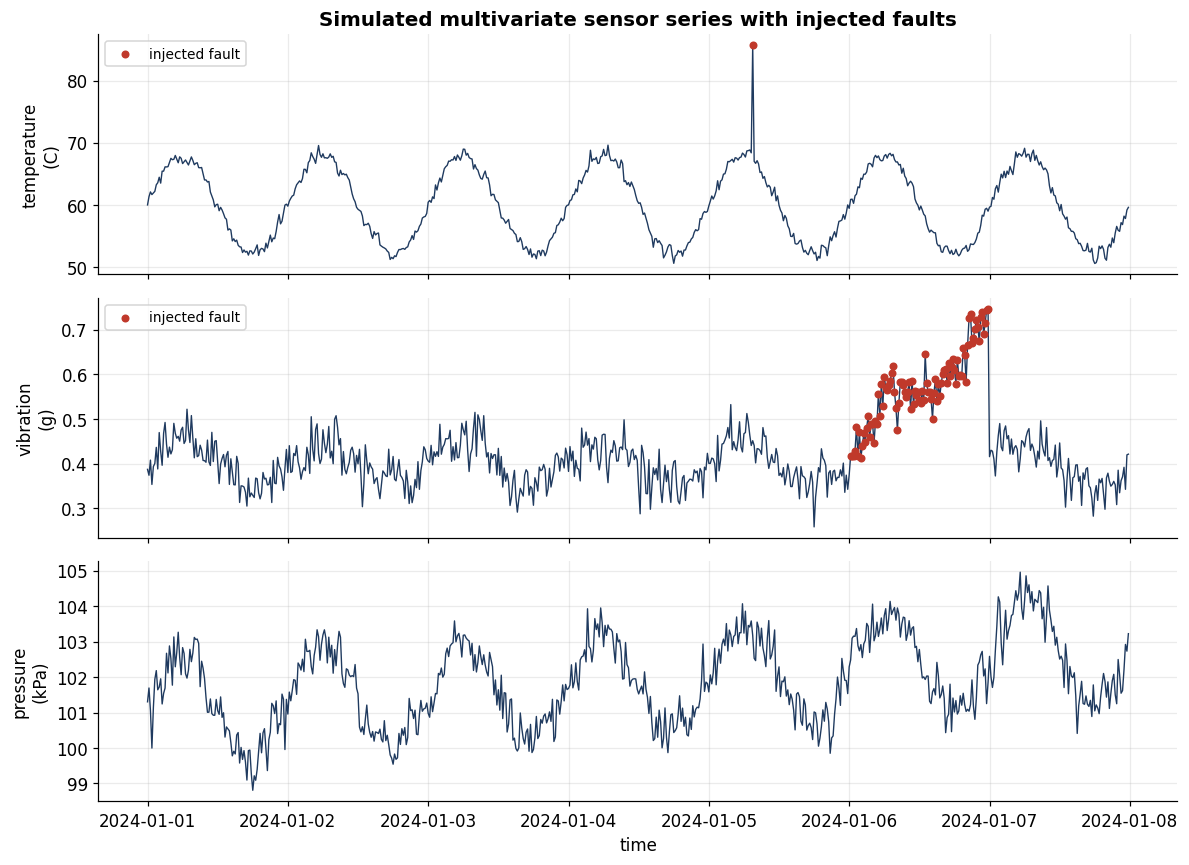

In [4]:
sensors = ['temperature', 'vibration', 'pressure']
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, sid in zip(axes, sensors):
    s = df[df.sensor_id == sid]
    ax.plot(s.timestamp, s.value, color=NAVY, lw=0.9)
    faults = s[s.is_anomaly]
    ax.scatter(faults.timestamp, faults.value, color=RED, s=18, zorder=5,
               label='injected fault')
    unit = s.unit.iloc[0]
    ax.set_ylabel(f'{sid}\n({unit})')
    if len(faults):
        ax.legend(loc='upper left', fontsize=9)
axes[0].set_title('Simulated multivariate sensor series with injected faults')
axes[-1].set_xlabel('time')
fig.tight_layout()

## 1.3 Seasonal profile

Averaging temperature by time-of-day recovers the imposed 24-hour cycle. This is why the feature layer adds **cyclical (sin/cos) calendar encodings** — they let a model see this structure as a smooth, continuous feature.

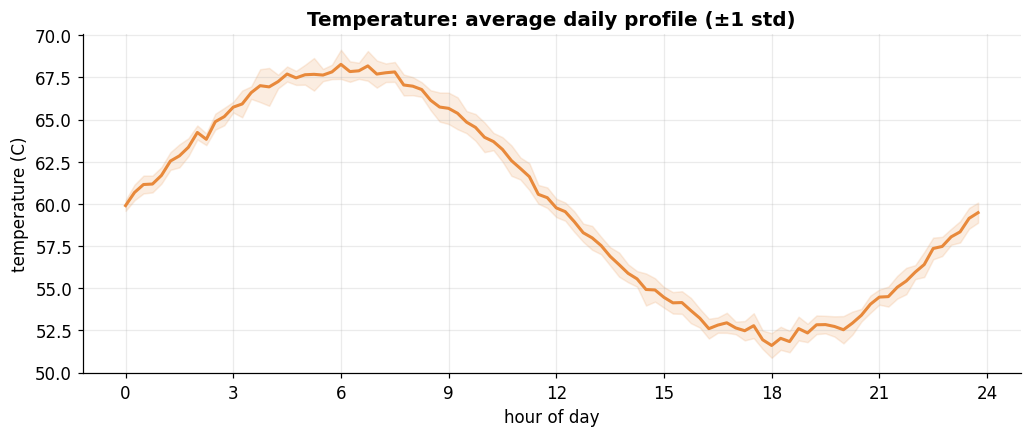

In [5]:
temp = df[df.sensor_id == 'temperature'].copy()
temp['minutes'] = temp.timestamp.dt.hour * 60 + temp.timestamp.dt.minute
profile = temp[~temp.is_anomaly].groupby('minutes').value.agg(['mean', 'std'])
hours = profile.index / 60
fig, ax = plt.subplots()
ax.plot(hours, profile['mean'], color=ORANGE, lw=2)
ax.fill_between(hours, profile['mean'] - profile['std'],
                profile['mean'] + profile['std'], color=ORANGE, alpha=0.15)
ax.set(title='Temperature: average daily profile (±1 std)',
       xlabel='hour of day', ylabel='temperature (C)')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

## 1.4 Noise structure

The noise is AR(1): each step is correlated with the previous one. The left panel shows the residual distribution after removing trend and seasonality is roughly Gaussian; the right panel shows the lag-1 autocorrelation the AR coefficient produces.

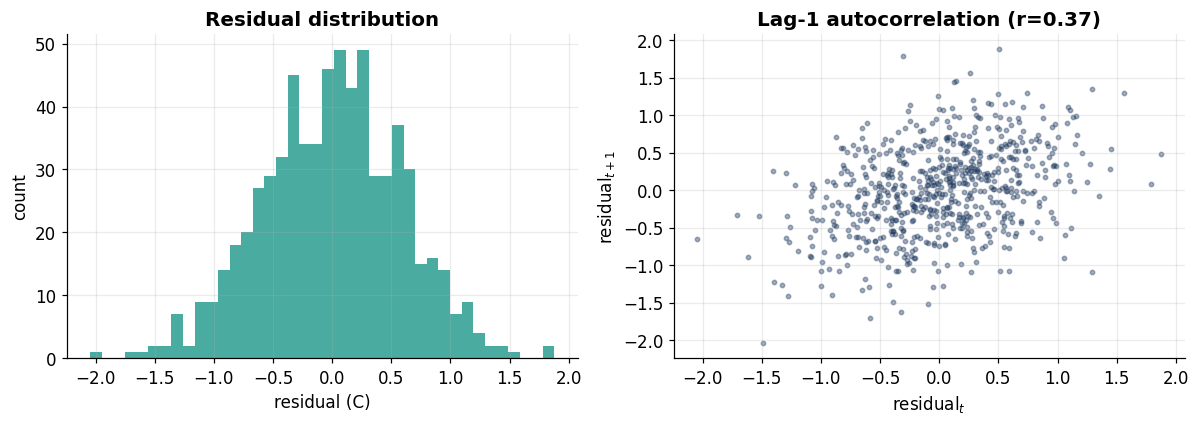

In [6]:
# Residual = observed - seasonal profile (temperature, fault-free).
clean = temp[~temp.is_anomaly].copy()
clean['resid'] = clean.value - clean.minutes.map(profile['mean'])
resid = clean.resid.to_numpy()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.hist(resid, bins=40, color=TEAL, alpha=0.85)
a1.set(title='Residual distribution', xlabel='residual (C)', ylabel='count')
a2.scatter(resid[:-1], resid[1:], s=8, color=NAVY, alpha=0.4)
a2.set(title=f'Lag-1 autocorrelation (r={np.corrcoef(resid[:-1], resid[1:])[0,1]:.2f})',
       xlabel='residual$_{t}$', ylabel='residual$_{t+1}$')
fig.tight_layout()

## Takeaways

- The simulator produces realistic, **reproducible** multivariate signals with trend, seasonality, and autocorrelated noise.
- Faults come in qualitatively different shapes (transient spike vs. slow drift), which is precisely why the platform needs *multiple* detection strategies.
- Ground-truth labels (`is_anomaly`) let us evaluate detectors quantitatively in notebook 3.

**Next:** [2 · Forecasting and Backtesting](02_forecasting_and_backtesting.ipynb).